In [46]:
library(readr)
library(dplyr)
library(ggplot2)
library(forecast)
library(tseries)
library(urca)
library(lmtest)
library(randtests)
library(nortest)

In [47]:
data <- read.csv("data/UNRATE.csv")
head(data)

,observation_date,UNRATE
,<chr>,<dbl>
1,1948-01-01,3.4
2,1948-02-01,3.8
3,1948-03-01,4.0
4,1948-04-01,3.9
5,1948-05-01,3.5
6,1948-06-01,3.6


In [48]:
summary(data)

 observation_date       UNRATE      
 Length:938         Min.   : 2.500  
 Class :character   1st Qu.: 4.300  
 Mode  :character   Median : 5.500  
                    Mean   : 5.664  
                    3rd Qu.: 6.700  
                    Max.   :14.800  
                    NA's   :1       

In [101]:
dft <- data |>
  select(time = observation_date, y = UNRATE) |>
  filter(time >= "2010-01-01" & time <= "2017-12-01") |>
  mutate(time = as.Date(time, format = "%Y-%m-%d")) |>
  arrange(time)

df_test <- data |>
  select(time = observation_date, y = UNRATE) |>
  filter(time >= "2018-01-01" & time <= "2019-12-01") |>
  mutate(time = as.Date(time, format = "%Y-%m-%d")) |>
  arrange(time)

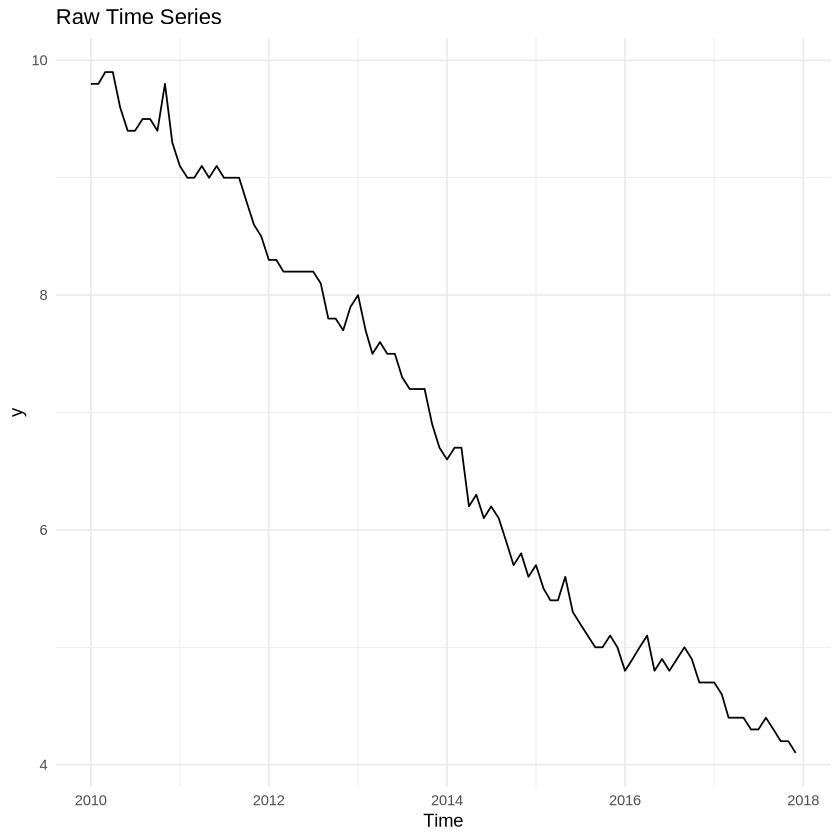

In [102]:
ggplot(dft, aes(x = time, y = y)) +
  geom_line() +
  labs(title = "Raw Time Series", x = "Time", y = "y") +
  theme_minimal()

In [103]:
summary(dft$y)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   4.10    5.00    6.70    6.83    8.35    9.90 

In [116]:

y_ts  <- ts(dft$y,      start = c(2010, 1), end = c(2017, 12), frequency = 12)
y_tst <- ts(df_test$y,  start = c(2018, 1), end = c(2019, 12), frequency = 12)

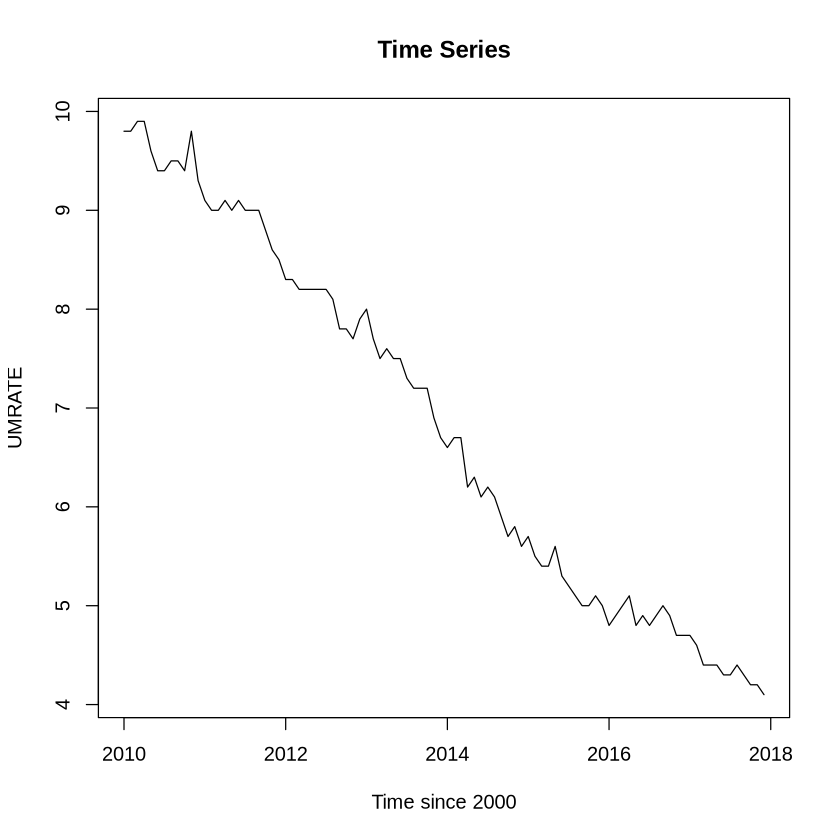

In [117]:
plot(y_ts, main = "Time Series", ylab = "UMRATE", xlab = "Time since 2000")

In [118]:
lambda <- BoxCox.lambda(y_ts)
lambda

[1] 0.7695527

In [119]:
y_bc <- BoxCox(y_ts, lambda)

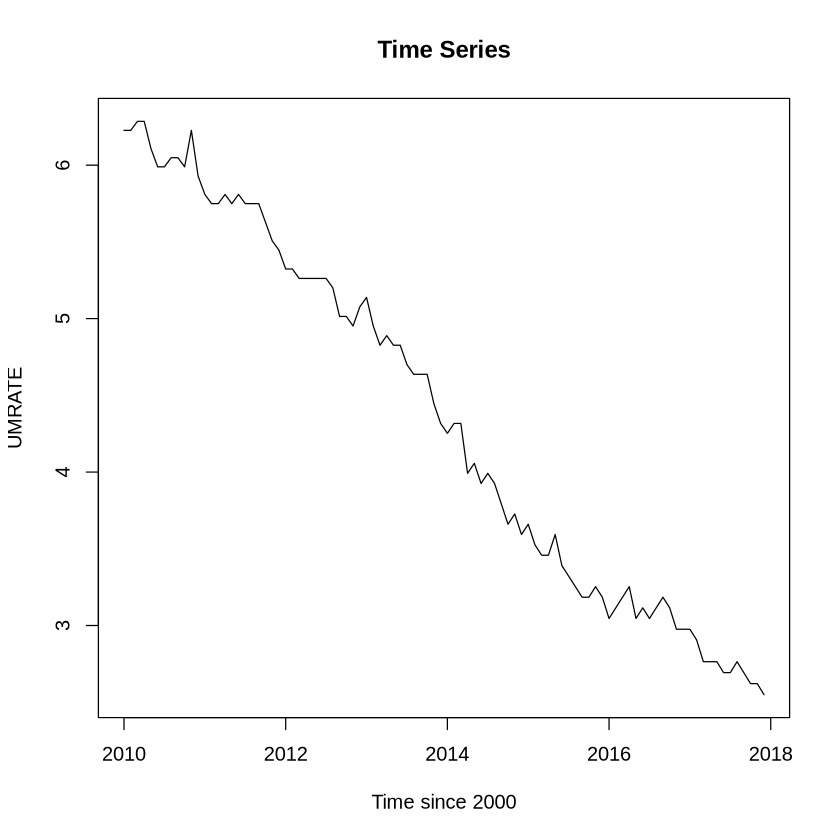

In [120]:
plot(y_bc, main = "Time Series", ylab = "UMRATE", xlab = "Time since 2000")


In [121]:
adf.test(y_bc)


	Augmented Dickey-Fuller Test

data:  y_bc
Dickey-Fuller = -1.1744, Lag order = 4, p-value = 0.9067
alternative hypothesis: stationary


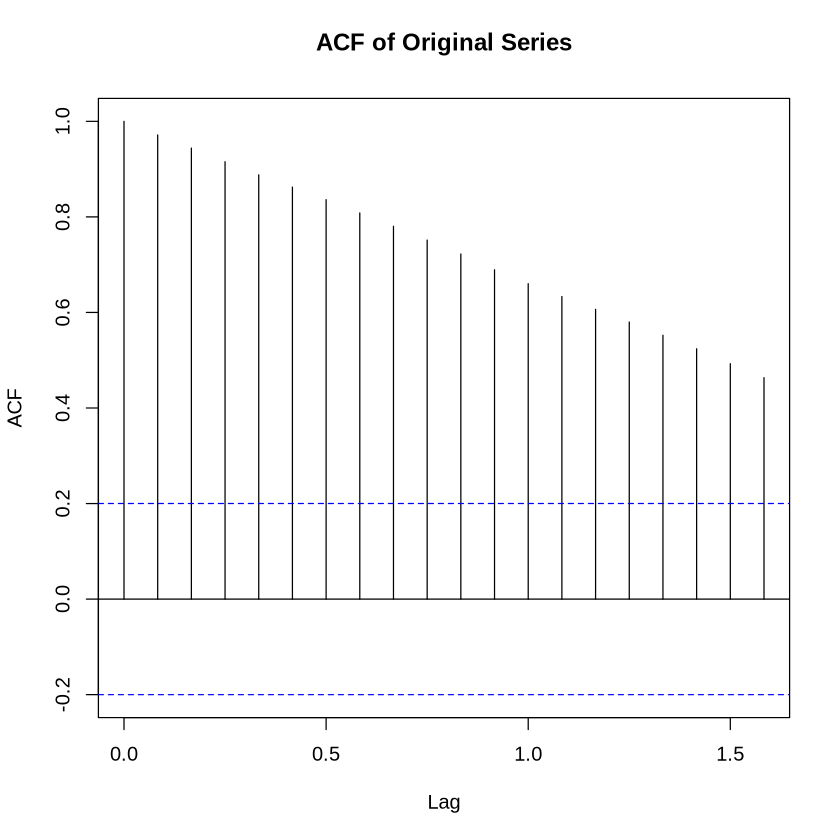

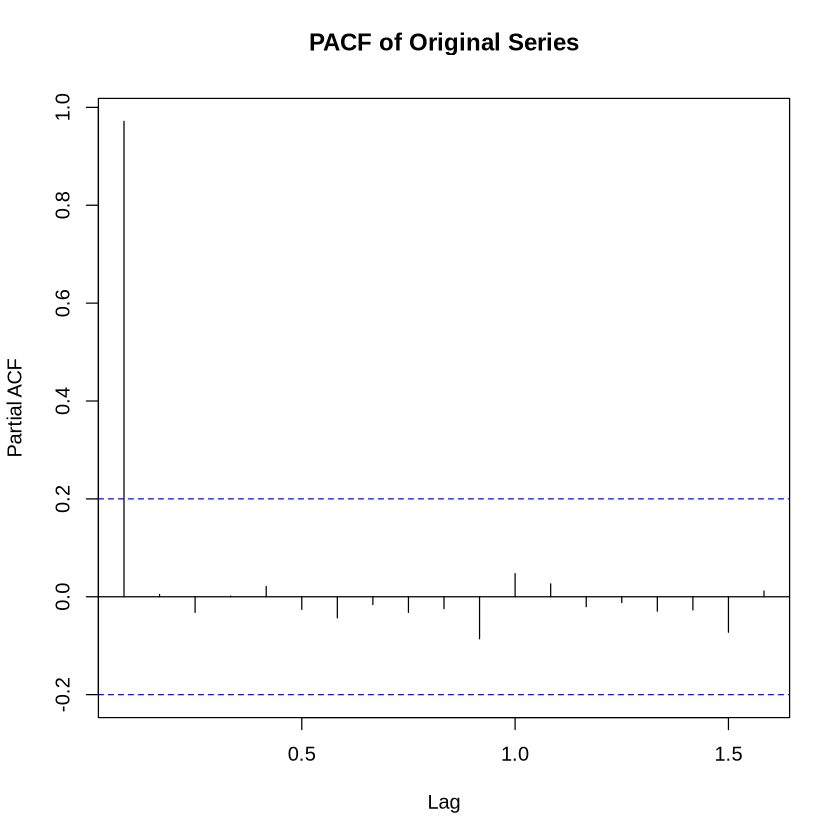

In [122]:
acf(y_bc, main = "ACF of Original Series")
pacf(y_bc, main = "PACF of Original Series")

In [129]:
arima_model <- arima(y_bc,
                     order = c(4, 1, 1))
summary(arima_model)


Call:
arima(x = y_bc, order = c(4, 1, 1))

Coefficients:
         ar1     ar2      ar3     ar4      ma1
      0.7206  0.0287  -0.0132  0.2624  -0.9687
s.e.  0.1268  0.1223   0.1224  0.1161   0.1546

sigma^2 estimated as 0.007668:  log likelihood = 95.28,  aic = -178.57

Training set error measures:
                     ME      RMSE        MAE         MPE     MAPE      MASE
Training set -0.0055887 0.0871097 0.06795895 -0.07095745 1.651376 0.1408078
                    ACF1
Training set -0.02169701


	Box-Ljung test

data:  res
X-squared = 18.851, df = 20, p-value = 0.5315



	Shapiro-Wilk normality test

data:  res[-1]
W = 0.98764, p-value = 0.5197


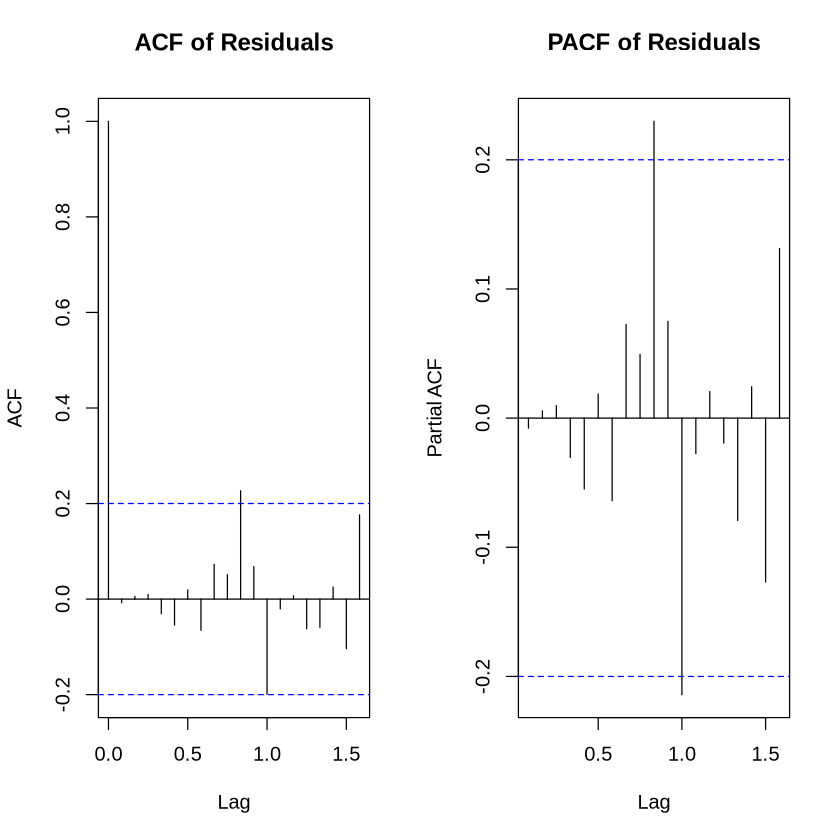

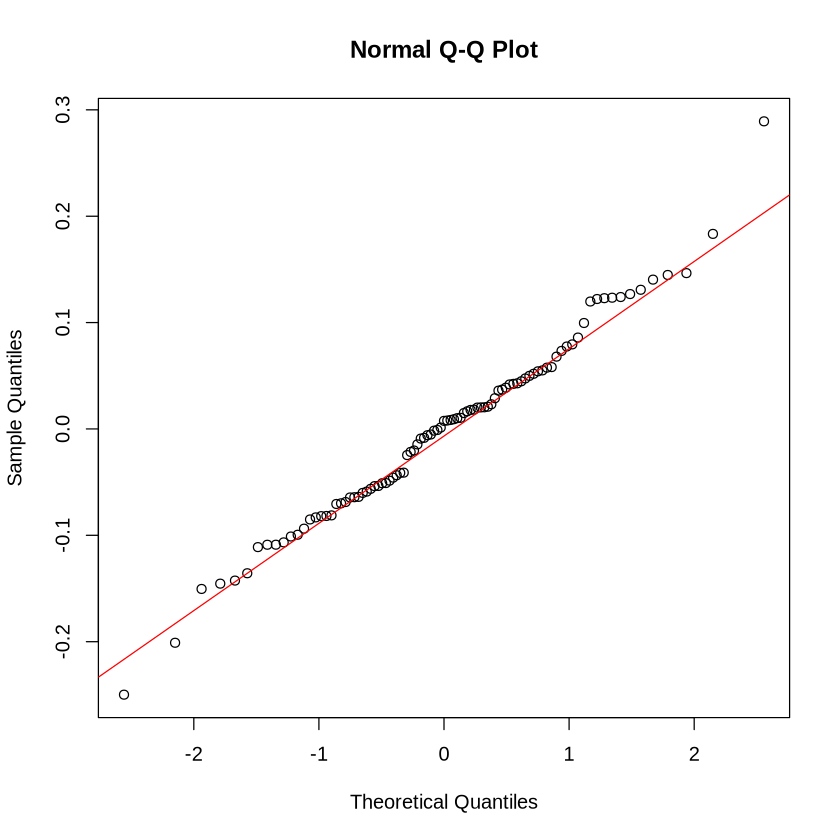

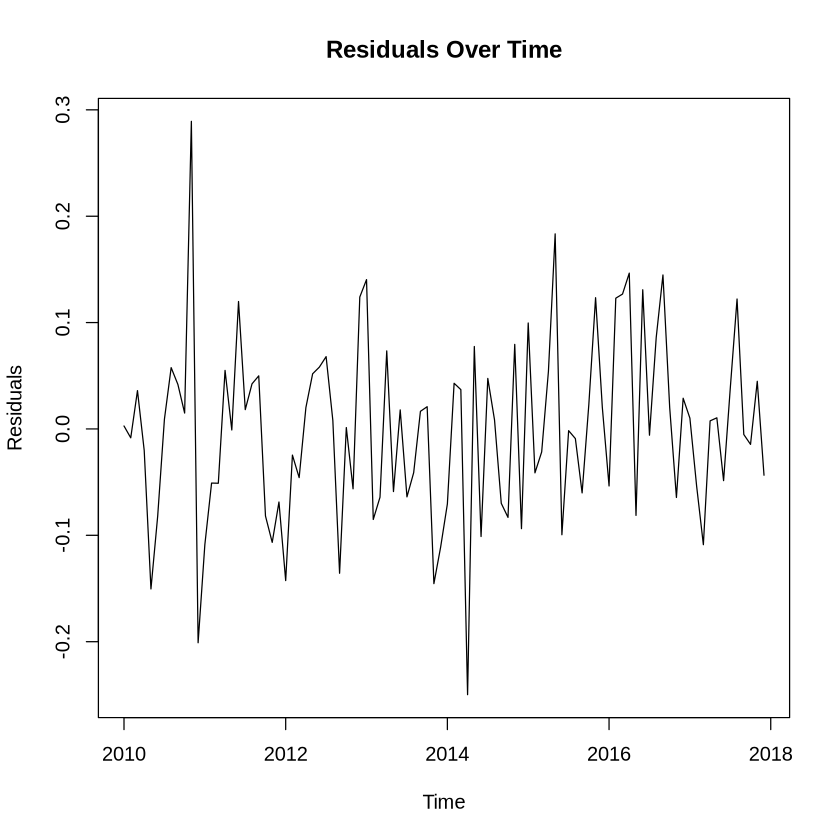

In [128]:
res <- residuals(arima_model)

# 1. Ljung-Box
Box.test(res, lag = 20, type = "Ljung-Box")

# 2. Shapiro-Wilk — drop first residual (initialization artifact)
shapiro.test(res[-1])

# 3. ACF & PACF of residuals
par(mfrow = c(1, 2))
acf(res,  main = "ACF of Residuals")
pacf(res, main = "PACF of Residuals")
par(mfrow = c(1, 1))

# 4. Q-Q plot
qqnorm(res[-1])
qqline(res[-1], col = "red")
plot(res, type = "l", main = "Residuals Over Time", ylab = "Residuals")

In [113]:
# Forecast 24 months (2018-2019)
fc <- forecast(arima_model, h = 24, lambda = lambda)

# Benchmarks
fc_naive  <- naive(y_ts,  h = 24)
fc_snaive <- snaive(y_ts, h = 24)
fit_ets   <- ets(y_bc)
fc_ets    <- forecast(fit_ets, h = 24, lambda = lambda)

# Accuracy table
cat("--- ARIMA ---\n");  print(accuracy(fc,        y_tst))
cat("--- ETS ---\n");    print(accuracy(fc_ets,    y_tst))
cat("--- Naive ---\n");  print(accuracy(fc_naive,  y_tst))
cat("--- SNaive ---\n"); print(accuracy(fc_snaive, y_tst))

Warning message in InvBoxCox(pred$pred, lambda, biasadj, pred$se^2):
“biasadj information not found, defaulting to FALSE.”


Warning message in forecast.ets(fit_ets, h = 24, lambda = lambda):
“biasadj information not found, defaulting to FALSE.”


--- ARIMA ---
                      ME      RMSE       MAE         MPE      MAPE      MASE
Training set -0.01072319 0.4706136 0.1594561  -0.9927739  3.036981 0.1507922
Test set     -3.11550665 3.1252039 3.1155067 -82.7804869 82.780487 2.9462295
                    ACF1 Theil's U
Training set 0.003701782        NA
Test set     0.812389213  29.23771
--- ETS ---
                       ME      RMSE       MAE         MPE      MAPE      MASE
Training set -0.005757358 0.4544316 0.1668106  -0.4165309  3.027654 0.1577472
Test set     -3.178662502 3.1822788 3.1786625 -84.2943854 84.294385 3.0059539
                   ACF1 Theil's U
Training set 0.03694344        NA
Test set     0.49288096  29.48822
--- Naive ---
                       ME     RMSE       MAE         MPE      MAPE      MASE
Training set -0.009253731 0.562006 0.1668657  -0.3999813  2.265214 0.1334925
Test set     -2.916666667 2.921330 2.9166667 -77.4274381 77.427438 2.3333333
                    ACF1 Theil's U
Training set -0.016325

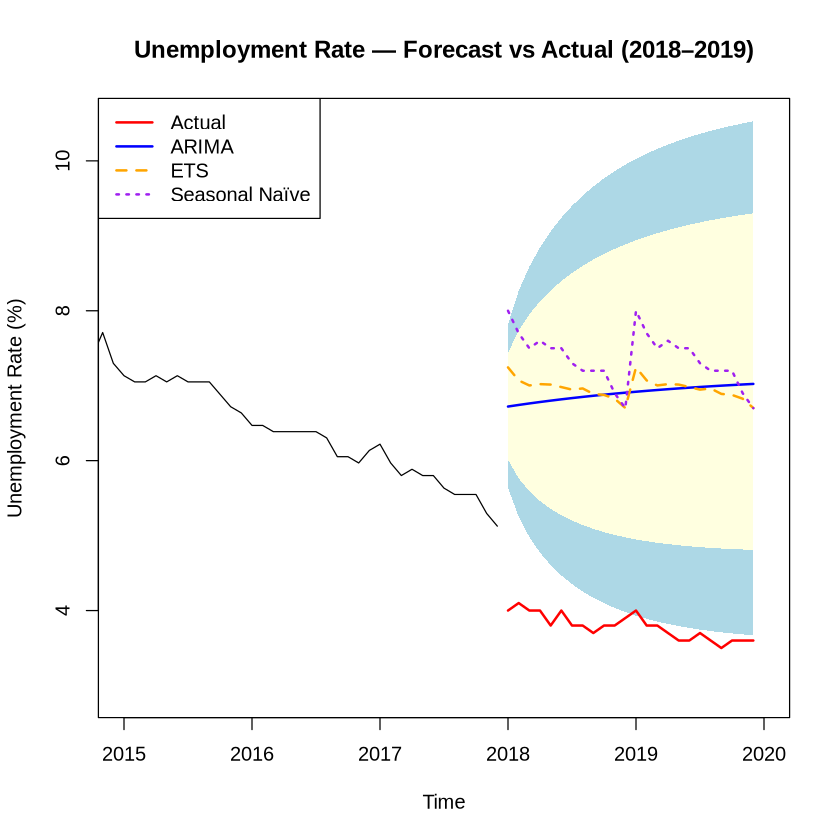

In [114]:
plot(fc,
     xlim = c(2015, 2020),
     main = "Unemployment Rate — Forecast vs Actual (2018–2019)",
     ylab = "Unemployment Rate (%)", xlab = "Time",
     fcol = "blue", shadecols = c("lightblue", "lightyellow"))

lines(y_tst,          col = "red",    lwd = 2)
lines(fc_ets$mean,    col = "orange", lwd = 2, lty = 2)
lines(fc_snaive$mean, col = "purple", lwd = 2, lty = 3)

legend("topleft",
       legend = c("Actual", "ARIMA", "ETS", "Seasonal Naïve"),
       col    = c("red", "blue", "orange", "purple"),
       lty    = c(1, 1, 2, 3), lwd = 2)

In [115]:
# Try forcing d=1 and compare AIC

AIC(arima_model)  # d=2 model
AIC(arima_d1)     # d=1 model

[1] 455.4226

[1] -793.0821